In [5]:
!pip install uproot

In [6]:
import uproot
import naive

In [7]:
#looking into ID lists in files:

fnaive_kT = uproot.open("naive_kt.root")
fnaive_antikt = uproot.open("naive_antikt.root")
fnaive_ca = uproot.open("naive_ca.root")

tree_naive_kT = fnaive_kT["finalJets"]
tree_naive_antikt = fnaive_antikt["finalJets"]
tree_naive_ca = fnaive_ca["finalJets"]

f_fj_kT = uproot.open("FJ_kt.root")
f_fj_antikt = uproot.open("FJ_antikt.root")
f_fj_ca = uproot.open("FJ_CA.root")

tree_fj_kT = f_fj_kT["finalJets"]
tree_fj_antikt = f_fj_antikt["finalJets"]
tree_fj_ca = f_fj_ca["finalJets"]

In [8]:
naive_kt_id = tree_naive_kT["id"].array()
naive_antikT_id = tree_naive_antikt["id"].array()
naive_ca_id = tree_naive_ca["id"].array()

fj_kt_id = tree_fj_kT["id"].array()
fj_antikt_id = tree_fj_antikt["id"].array()
fj_ca_id = tree_fj_ca["id"].array()

In [9]:
##Have a quick look inside what is collected from the files:

In [10]:
print(naive_kt_id)

[[136], [95], [142], [92], ..., [128, 123, 66], [111, 25], [77, 75, 76, 74]]


In [11]:
print(fj_kt_id)

[[74, 76, 75, 77], [25, 111], [66, 123, 128], [...], ..., [142], [95], [136]]


In [12]:
#Bring in pT's; we will sort and compare by pT's (at least for now)

In [13]:
naive_kt_pT = tree_naive_kT["pT"].array()
naive_antikt_pT = tree_naive_antikt["pT"].array()
naive_ca_pT = tree_naive_ca["pT"].array()

fj_kt_pT = tree_fj_kT["pT"].array()
fj_antikt_pT = tree_fj_antikt["pT"].array()
fj_ca_pT = tree_fj_ca["pT"].array()

In [14]:
#pair up jet id lists with corresponding pT values

In [15]:
naive_kT = list(zip(naive_kt_id, naive_kt_pT))
naive_antikt = list(zip(naive_antikT_id, naive_antikt_pT))
naive_ca = list(zip(naive_ca_id, naive_ca_pT))

In [16]:
#Custom function to turn the elements of the id lists
#into standard ints instead of np.int

In [17]:
def convert_to_standard_ids(input_naive):
  new_naive_kT = []
  for ids_list, pt_value in input_naive:
    # Convert each np.int64 in the ids_list to a standard int
    converted_ids = [int(an_id) for an_id in ids_list]
    new_naive_kT.append((converted_ids, pt_value))
  return new_naive_kT

naive_kT = convert_to_standard_ids(naive_kT)
naive_antikt = convert_to_standard_ids(naive_antikt)
naive_ca = convert_to_standard_ids(naive_ca)

In [18]:
print(naive_kT) # Print first 5 elements to verify the change

[([136], np.float64(0.012049639277675672)), ([95], np.float64(0.014818349389645798)), ([142], np.float64(0.018280885068823298)), ([92], np.float64(0.018633515294420224)), ([118], np.float64(0.033234113667291044)), ([86], np.float64(0.04178493354001943)), ([125], np.float64(0.04398072954180957)), ([101], np.float64(0.05049338613916134)), ([65], np.float64(0.050496466190054816)), ([82], np.float64(0.05628667837972944)), ([59], np.float64(0.05930638371905532)), ([127], np.float64(0.06430840316979418)), ([114], np.float64(0.07480303768118077)), ([7], np.float64(0.08262233504238699)), ([98], np.float64(0.0851656473495536)), ([91], np.float64(0.09019963583852507)), ([49], np.float64(0.09914327834144504)), ([107], np.float64(0.10832337050018614)), ([112], np.float64(0.12312651258824113)), ([108], np.float64(0.13559691548043226)), ([130], np.float64(0.13746713592825943)), ([71], np.float64(0.13928525918963602)), ([134], np.float64(0.14423609722572292)), ([37], np.float64(0.1476145906017086)), 

In [19]:
naive_kT = sorted(naive_kT, key=lambda x: x[1])
naive_antikt = sorted(naive_antikt, key=lambda x: x[1])
naive_ca = sorted(naive_ca, key=lambda x: x[1])
#

In [20]:
#repeat process for fj data sets

fj_kT = list(zip(fj_kt_id, fj_kt_pT))
fj_antikt = list(zip(fj_antikt_id, fj_antikt_pT))
fj_ca = list(zip(fj_ca_id, fj_ca_pT))
#

In [21]:
fj_kT = convert_to_standard_ids(fj_kT)
fj_antikt = convert_to_standard_ids(fj_antikt)
fj_ca = convert_to_standard_ids(fj_ca)


In [22]:
fj_kT = sorted(fj_kT, key=lambda x: x[1])
fj_antikt = sorted(fj_antikt, key=lambda x: x[1])
fj_ca = sorted(fj_ca, key=lambda x: x[1])
#

In [23]:
print(fj_kT)

[([136], np.float64(0.012049639277675672)), ([95], np.float64(0.014818349389645798)), ([142], np.float64(0.018280885068823298)), ([92], np.float64(0.018633515294420224)), ([125], np.float64(0.04398072954180957)), ([101], np.float64(0.05049338613916134)), ([82], np.float64(0.05628667837972944)), ([127], np.float64(0.06430840316979418)), ([114], np.float64(0.07480303768118077)), ([7], np.float64(0.08262233504238699)), ([65, 118], np.float64(0.08340566402599585)), ([98], np.float64(0.0851656473495536)), ([139], np.float64(0.08956611313935828)), ([91], np.float64(0.09019963583852507)), ([49], np.float64(0.09914327834144504)), ([107], np.float64(0.10832337050018614)), ([112], np.float64(0.12312651258824113)), ([108], np.float64(0.13559691548043226)), ([81], np.float64(0.15324234682383836)), ([105], np.float64(0.16426785018193482)), ([84], np.float64(0.1768408727931937)), ([109], np.float64(0.22683374718136537)), ([39], np.float64(0.23017475315706817)), ([43], np.float64(0.2322696123008197))

In [24]:
len(fj_kT)

99

In [25]:
#Finally running the actual comparison:
#want to map every ith jet in <fj> sets
# to every 7 nearest jets in <naive> sets

#i.e., compare fj_jet[i] to naive_jet[i-3], naive_jet[i-2], naive_jet[i-1], naive_jet[i], ..., naive_jet[i+3]

#N = len(<fj> set)

In [26]:
#scan for duplicate particles in <naive>?

def check_for_duplicates(naive_set):
  """

  """
  tagged = []

  for id,pt in naive_set:
    for index in id:
      if index in tagged:
        return True
      else:
        tagged.append(index)
  return False

check_for_duplicates(naive_ca)
#

False

In [27]:
def same_elements(list1, list2):
    return set(list1) == set(list2)

def compare_sets(fj_set, naive_set):
  """
  Takes the fj_set and naive_set of final jets;
  Iterates over each x[0] list of constituents for each jet in fj_set,
    then scans through each y[0] list of constituents for each jet in naive_set,
  If a match is found, the two matched jets are added to the matches list,
    and marked as used.
  Finally, it returns the jets from both sets that remain unmatched.
  """

  matched_pairs = []
  unmatched_fj = []
  # Create a mutable copy and a way to track used naive jets
  temp_naive_set = naive_set
  naive_used = [False] * len(temp_naive_set) #flagging whether a match is found in the ith element of naive_set

  for fj_jet in fj_set:
    matched = False
    for i, naive_jet in enumerate(temp_naive_set):
      if not naive_used[i] and same_elements(fj_jet[0], naive_jet[0]):
        print(f"Match found: FJ jet: {fj_jet[0]} ; Naive jet: {naive_jet[0]}")
        matched_pairs.append((fj_jet, naive_jet))
        naive_used[i] = True  # Mark this naive jet as used
        matched = True
        break  # Move to the next fj_jet since a match was found for the current one

    if not matched:
      unmatched_fj.append(fj_jet)

  # Collect the naive jets that were not matched/used
  unmatched_naive = [naive_jet for i, naive_jet in enumerate(temp_naive_set) if not naive_used[i]]

  return unmatched_fj, unmatched_naive, matched_pairs

In [28]:
new_fj_kT, new_naive_kT, kt_matches = compare_sets(fj_kT, naive_kT)

Match found: FJ jet: [136] ; Naive jet: [136]
Match found: FJ jet: [95] ; Naive jet: [95]
Match found: FJ jet: [142] ; Naive jet: [142]
Match found: FJ jet: [92] ; Naive jet: [92]
Match found: FJ jet: [125] ; Naive jet: [125]
Match found: FJ jet: [101] ; Naive jet: [101]
Match found: FJ jet: [82] ; Naive jet: [82]
Match found: FJ jet: [127] ; Naive jet: [127]
Match found: FJ jet: [114] ; Naive jet: [114]
Match found: FJ jet: [7] ; Naive jet: [7]
Match found: FJ jet: [98] ; Naive jet: [98]
Match found: FJ jet: [91] ; Naive jet: [91]
Match found: FJ jet: [49] ; Naive jet: [49]
Match found: FJ jet: [107] ; Naive jet: [107]
Match found: FJ jet: [112] ; Naive jet: [112]
Match found: FJ jet: [108] ; Naive jet: [108]
Match found: FJ jet: [81] ; Naive jet: [81]
Match found: FJ jet: [105] ; Naive jet: [105]
Match found: FJ jet: [84] ; Naive jet: [84]
Match found: FJ jet: [109] ; Naive jet: [109]
Match found: FJ jet: [39] ; Naive jet: [39]
Match found: FJ jet: [43] ; Naive jet: [43]
Match found:

In [29]:
print(f"Length of new_fj_kT (unmatched FJ jets): {len(new_fj_kT)}")

Length of new_fj_kT (unmatched FJ jets): 26


In [30]:
print(f"Length of new_naive_kT (unmatched naive jets): {len(new_naive_kT)}")

Length of new_naive_kT (unmatched naive jets): 29


In [31]:
#KT unmatched:
print("KT unmatched jets:")
for new_naive_kT_jet in new_naive_kT:
  print(f"constituents {new_naive_kT_jet[0]} // pT: {float(new_naive_kT_jet[1])}")

print("FJ unmatched jets:")
for new_fj_kT_jet in new_fj_kT:
  print(f"constituents {new_fj_kT_jet[0]} // pT: {float(new_fj_kT_jet[1])}")

KT unmatched jets:
constituents [118] // pT: 0.033234113667291044
constituents [86] // pT: 0.04178493354001943
constituents [65] // pT: 0.050496466190054816
constituents [59] // pT: 0.05930638371905532
constituents [130] // pT: 0.13746713592825943
constituents [71] // pT: 0.13928525918963602
constituents [134] // pT: 0.14423609722572292
constituents [37] // pT: 0.1476145906017086
constituents [38] // pT: 0.20995864135601094
constituents [27] // pT: 0.2645529232269104
constituents [135] // pT: 0.2989821033553596
constituents [22] // pT: 0.30850782780859404
constituents [89, 57] // pT: 0.3395875135395832
constituents [21] // pT: 0.34369351837805007
constituents [100] // pT: 0.4578266299230895
constituents [140, 13] // pT: 0.5651264843078155
constituents [96] // pT: 0.611987773691963
constituents [129, 67] // pT: 0.6759531517977173
constituents [90, 29] // pT: 0.701528204554685
constituents [139, 14] // pT: 0.7088594037421152
constituents [31] // pT: 0.7347934968656961
constituents [17, 1

In [32]:
#doing same thing for CA and antikT algorithms

new_fj_antikt, new_naive_antikt, antikT_matches = compare_sets(fj_antikt, naive_antikt)

Match found: FJ jet: [103] ; Naive jet: [103]
Match found: FJ jet: [6] ; Naive jet: [6]
Match found: FJ jet: [41] ; Naive jet: [41]
Match found: FJ jet: [45] ; Naive jet: [45]
Match found: FJ jet: [2] ; Naive jet: [2]
Match found: FJ jet: [28, 79] ; Naive jet: [79, 28]
Match found: FJ jet: [16] ; Naive jet: [16]


In [33]:
new_fj_ca, new_naive_ca, ca_matches = compare_sets(fj_ca, naive_ca)

Match found: FJ jet: [103] ; Naive jet: [103]
Match found: FJ jet: [6] ; Naive jet: [6]
Match found: FJ jet: [41] ; Naive jet: [41]
Match found: FJ jet: [44] ; Naive jet: [44]
Match found: FJ jet: [45] ; Naive jet: [45]
Match found: FJ jet: [36] ; Naive jet: [36]
Match found: FJ jet: [2] ; Naive jet: [2]
Match found: FJ jet: [28, 79] ; Naive jet: [79, 28]
Match found: FJ jet: [110, 40, 56] ; Naive jet: [110, 56, 40]
Match found: FJ jet: [16] ; Naive jet: [16]
Match found: FJ jet: [25, 111] ; Naive jet: [111, 25]


In [34]:
#lengths:

print(len(new_naive_antikt))
print(len(new_fj_antikt))
print(len(new_naive_ca))
print(len(new_fj_ca))

42
92
38
88


In [35]:
print(len(antikT_matches))
print(len(ca_matches))

7
11


In [36]:
print("antikt unmatched jets:")
for new_naive_antikt_jet in new_naive_antikt:
  print(f"constituents {new_naive_antikt_jet[0]} // pT: {float(new_naive_antikt_jet[1])}")
print("FJ unmatched jets:")
for new_fj_antikt_jet in new_fj_antikt:
  print(f"constituents {new_fj_antikt_jet[0]} // pT: {float(new_fj_antikt_jet[1])}")
#

antikt unmatched jets:
constituents [101, 98, 102] // pT: 0.450225223154267
constituents [127, 109, 108, 39] // pT: 0.5203904964080314
constituents [121, 54] // pT: 0.5328233446937951
constituents [91, 78, 7, 112] // pT: 0.5726616666778553
constituents [137, 88] // pT: 0.7119314247017676
constituents [31] // pT: 0.7347934968656961
constituents [67, 49, 129] // pT: 0.7536107744458519
constituents [92, 62, 114, 24] // pT: 0.7672742972543125
constituents [104, 70, 71, 105] // pT: 0.7964919185844024
constituents [130, 90, 29] // pT: 0.8136589718119068
constituents [63, 61] // pT: 0.8189136871275048
constituents [25] // pT: 0.8259758619756573
constituents [36, 1] // pT: 0.8348774558268196
constituents [89, 57, 42, 27] // pT: 0.8506256888830145
constituents [140, 13, 53] // pT: 0.8709973162053369
constituents [32, 3, 83] // pT: 0.8857264859306401
constituents [113, 59, 5] // pT: 0.8888472330939728
constituents [107, 106] // pT: 0.9117404447912781
constituents [131, 26, 43] // pT: 0.958669936

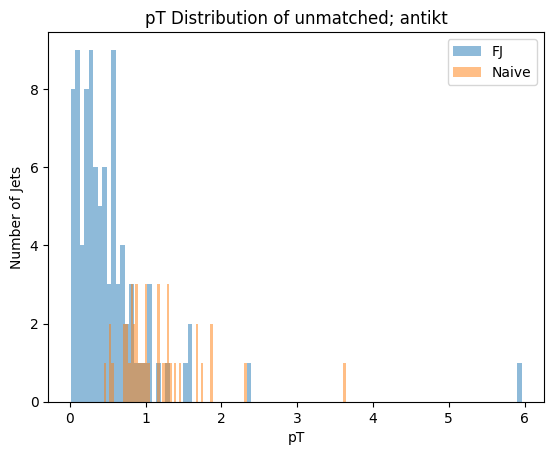

In [37]:
import matplotlib.pyplot as plt

unmatchedAntikt_fj_pT = [jet[1] for jet in new_fj_antikt]
unmatchedAntikt_naive_pT = [jet[1] for jet in new_naive_antikt]

plt.hist(unmatchedAntikt_fj_pT, bins=100, alpha=0.5, label='FJ')
plt.hist(unmatchedAntikt_naive_pT, bins=100, alpha=0.5, label='Naive')
plt.xlabel('pT')
plt.ylabel('Number of Jets') # Changed from 'Frequency'
plt.title('pT Distribution of unmatched; antikt')
plt.legend()
plt.show()

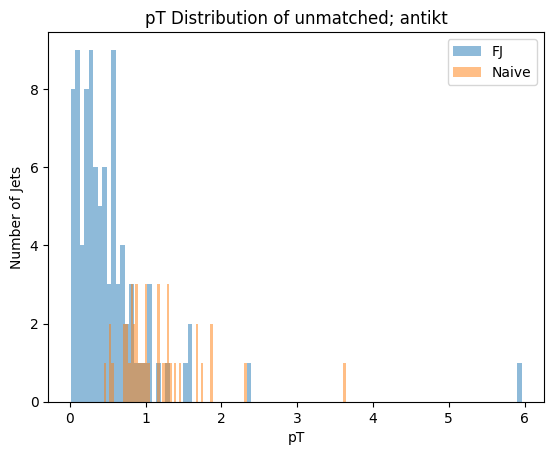

In [38]:
#same for ca:

unmatchedCA_fj_pT = [jet[1] for jet in new_fj_antikt]
unmatchedCA_naive_pT = [jet[1] for jet in new_naive_antikt]

plt.hist(unmatchedCA_fj_pT, bins=100, alpha=0.5, label='FJ')
plt.hist(unmatchedCA_naive_pT, bins=100, alpha=0.5, label='Naive')
plt.xlabel('pT')
plt.ylabel('Number of Jets') # Changed from 'Frequency'
plt.title('pT Distribution of unmatched; antikt')
plt.legend()
plt.show()

In [39]:
##Looking deeper into outputs:
naive_kt_E = tree_naive_kT["E"].array()
naive_antikt_E = tree_naive_antikt["E"].array()
naive_ca_E = tree_naive_ca["E"].array()

fj_kt_E = tree_fj_kT["E"].array()
fj_antikt_E = tree_fj_antikt["E"].array()
fj_ca_E = tree_fj_ca["E"].array()
#

naive_kt_px = tree_naive_kT["px"].array()
naive_antikt_px = tree_naive_antikt["px"].array()
naive_ca_px = tree_naive_ca["px"].array()

fj_kt_px = tree_fj_kT["px"].array()
fj_antikt_px = tree_fj_antikt["px"].array()
fj_ca_px = tree_fj_ca["px"].array()
#

naive_kt_py = tree_naive_kT["py"].array()
naive_antikt_py = tree_naive_antikt["py"].array()
naive_ca_py = tree_naive_ca["py"].array()

fj_kt_py = tree_fj_kT["py"].array()
fj_antikt_py = tree_fj_antikt["py"].array()
fj_ca_py = tree_fj_ca["py"].array()
#

naive_kt_pz = tree_naive_kT["pz"].array()
naive_antikt_pz = tree_naive_antikt["pz"].array()
naive_ca_pz = tree_naive_ca["pz"].array()

fj_kt_pz = tree_fj_kT["pz"].array()
fj_antikt_pz = tree_fj_antikt["pz"].array()
fj_ca_pz = tree_fj_ca["pz"].array()
#



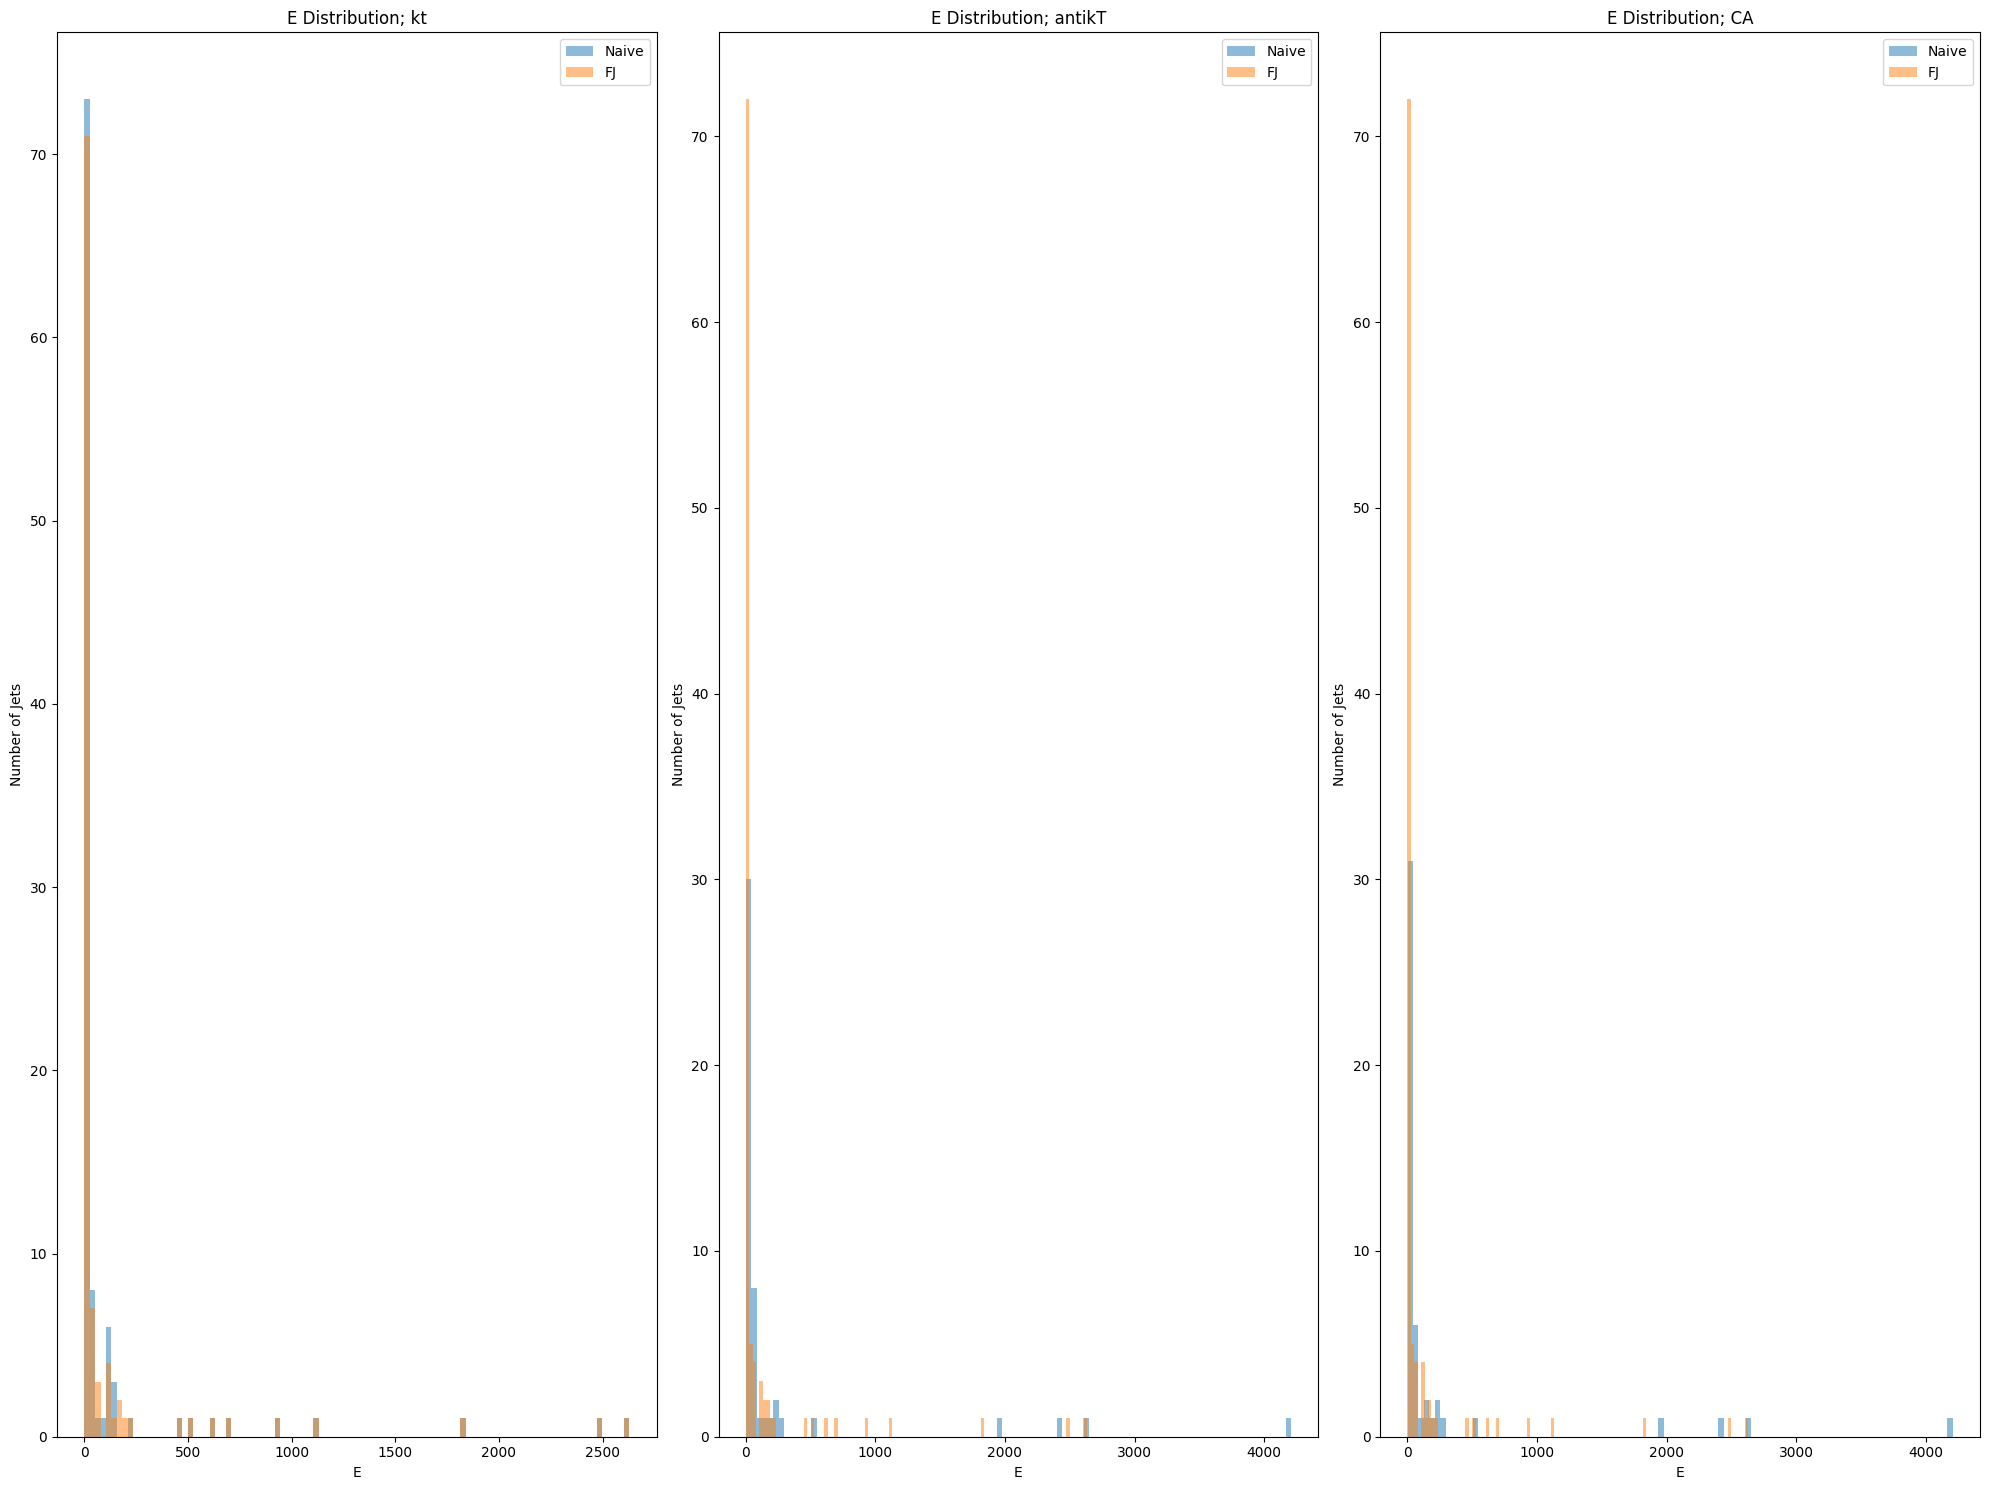

In [58]:
import matplotlib.pyplot as plt

#E DISTRIBUTION
fig, axes = plt.subplots(1, 3, figsize=(20, 15))

# Plot for E Distribution; kt
axes[0].hist(naive_kt_E, bins=100, alpha=0.5, label='Naive')
axes[0].hist(fj_kt_E, bins=100, alpha=0.5, label='FJ')
axes[0].set_xlabel('E')
axes[0].set_ylabel('Number of Jets')
axes[0].set_title('E Distribution; kt')
axes[0].legend()

#antikT
axes[1].hist(naive_antikt_E, bins=100, alpha=0.5, label='Naive')
axes[1].hist(fj_antikt_E, bins=100, alpha=0.5, label='FJ')
axes[1].set_xlabel('E')
axes[1].set_ylabel('Number of Jets')
axes[1].set_title('E Distribution; antikT')
axes[1].legend()

#CA

axes[2].hist(naive_ca_E, bins=100, alpha=0.5, label='Naive')
axes[2].hist(fj_ca_E, bins=100, alpha=0.5, label='FJ')
axes[2].set_xlabel('E')
axes[2].set_ylabel('Number of Jets')
axes[2].set_title('E Distribution; CA')
axes[2].legend()

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()
plt.show()

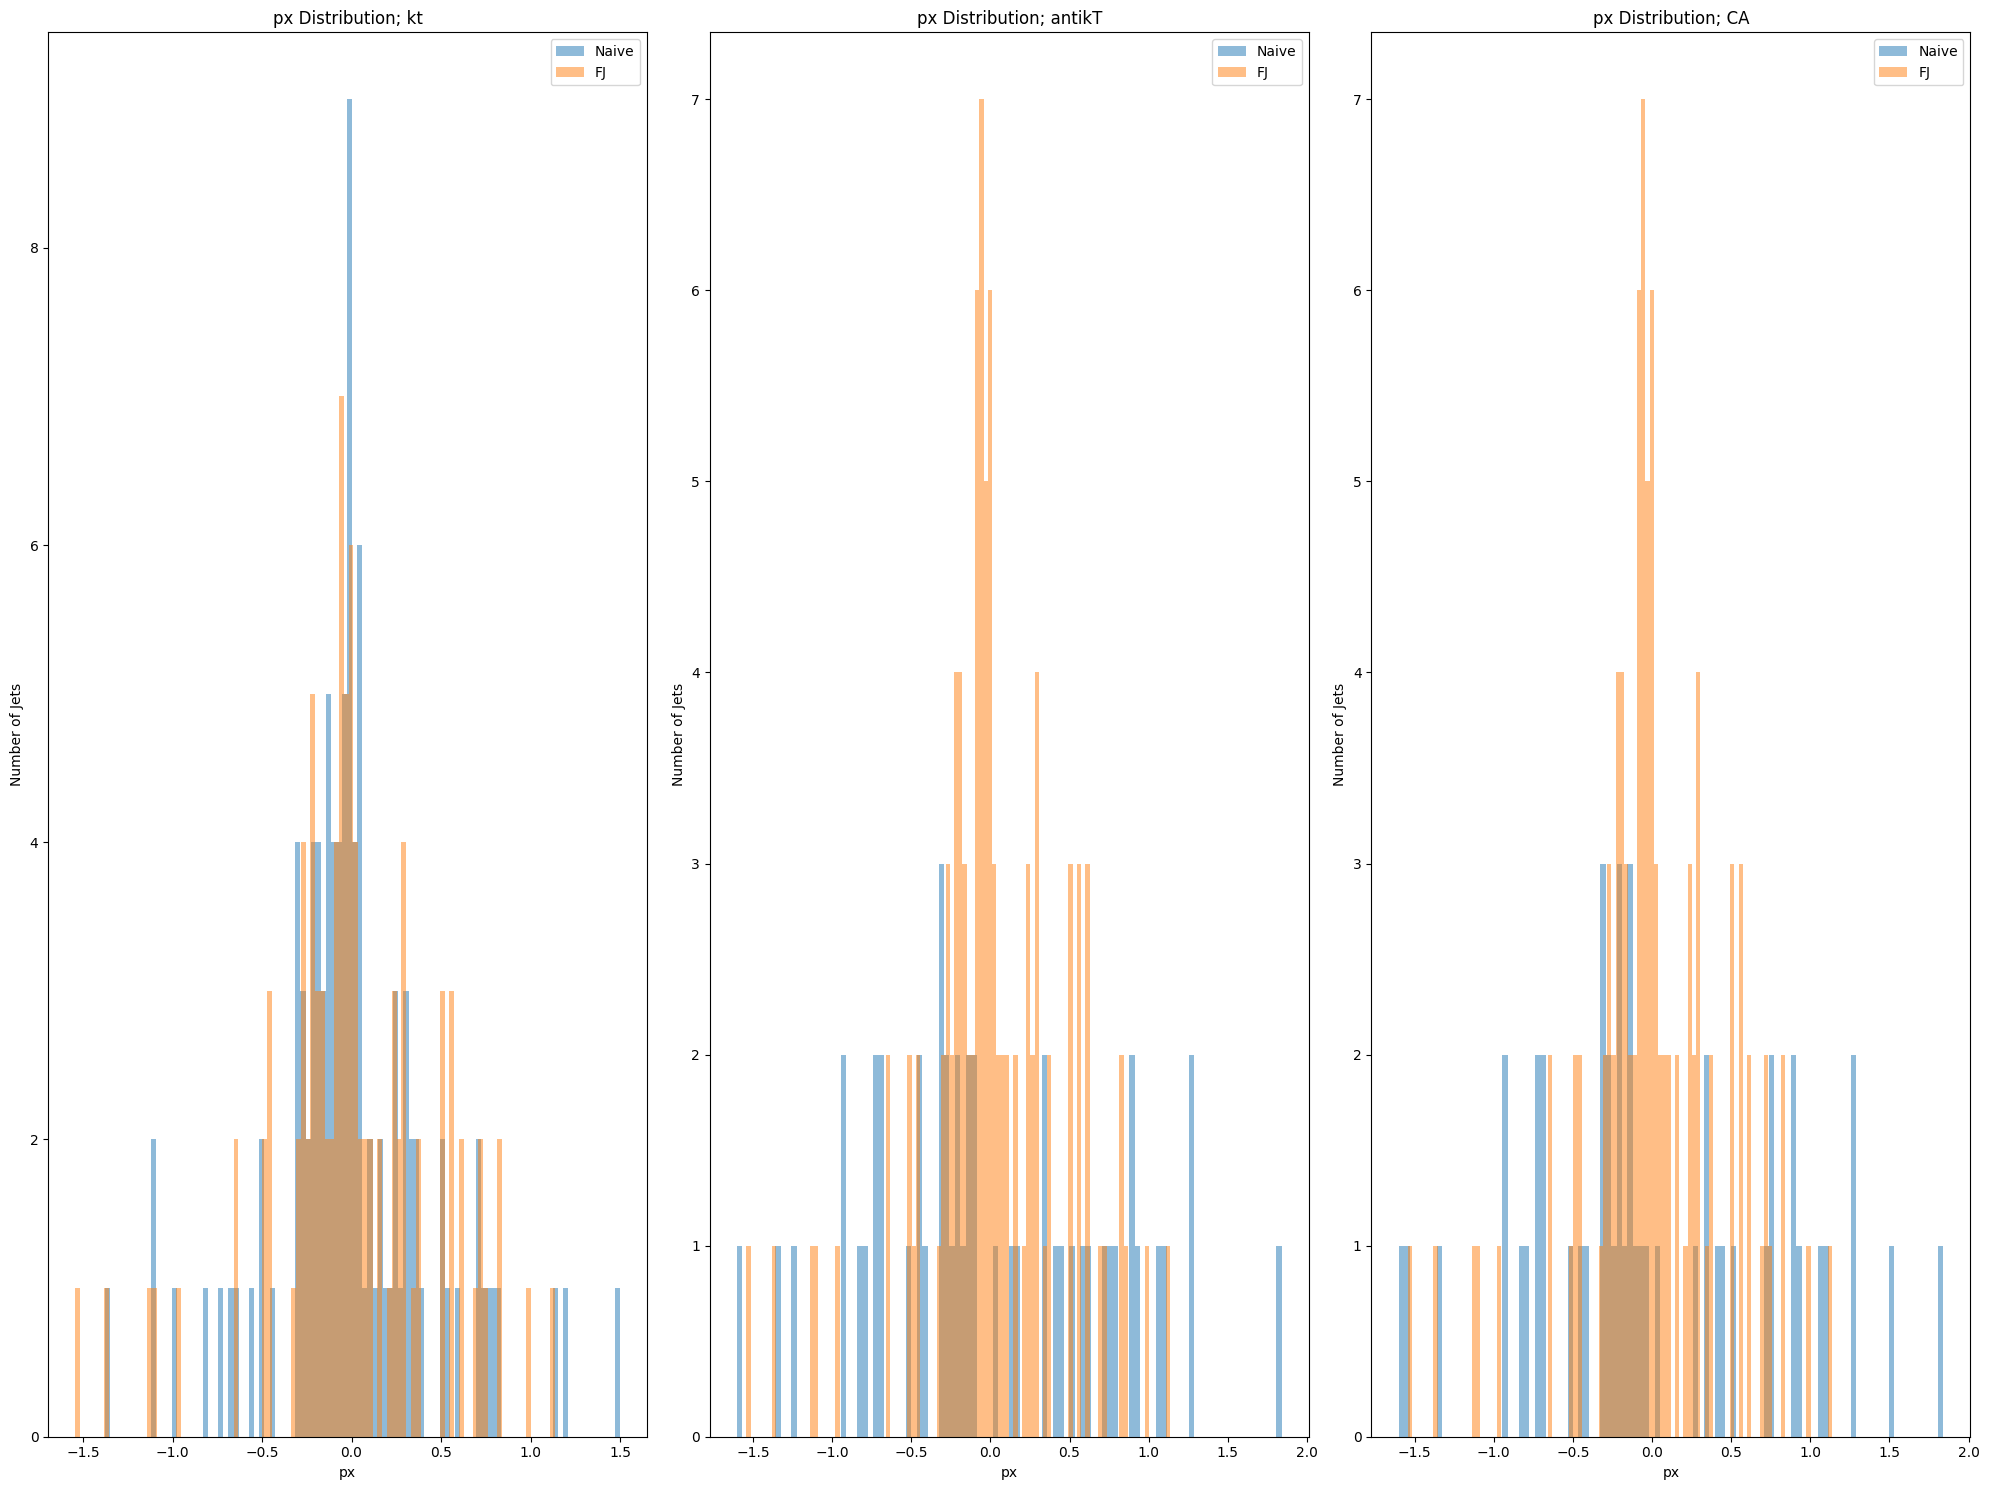

In [59]:
figpx, axespx = plt.subplots(1, 3, figsize=(20, 15))

axespx[0].hist(naive_kt_px, bins=100, alpha=0.5, label='Naive')
axespx[0].hist(fj_kt_px, bins=100, alpha=0.5, label='FJ')
axespx[0].set_xlabel('px')
axespx[0].set_ylabel('Number of Jets')
axespx[0].set_title('px Distribution; kt')
axespx[0].legend()

axespx[1].hist(naive_antikt_px, bins=100, alpha=0.5, label='Naive')
axespx[1].hist(fj_antikt_px, bins=100, alpha=0.5, label='FJ')
axespx[1].set_xlabel('px')
axespx[1].set_ylabel('Number of Jets')
axespx[1].set_title('px Distribution; antikT')
axespx[1].legend()

axespx[2].hist(naive_ca_px, bins=100, alpha=0.5, label='Naive')
axespx[2].hist(fj_ca_px, bins=100, alpha=0.5, label='FJ')
axespx[2].set_xlabel('px')
axespx[2].set_ylabel('Number of Jets')
axespx[2].set_title('px Distribution; CA')
axespx[2].legend()

plt.tight_layout()
plt.show()
#



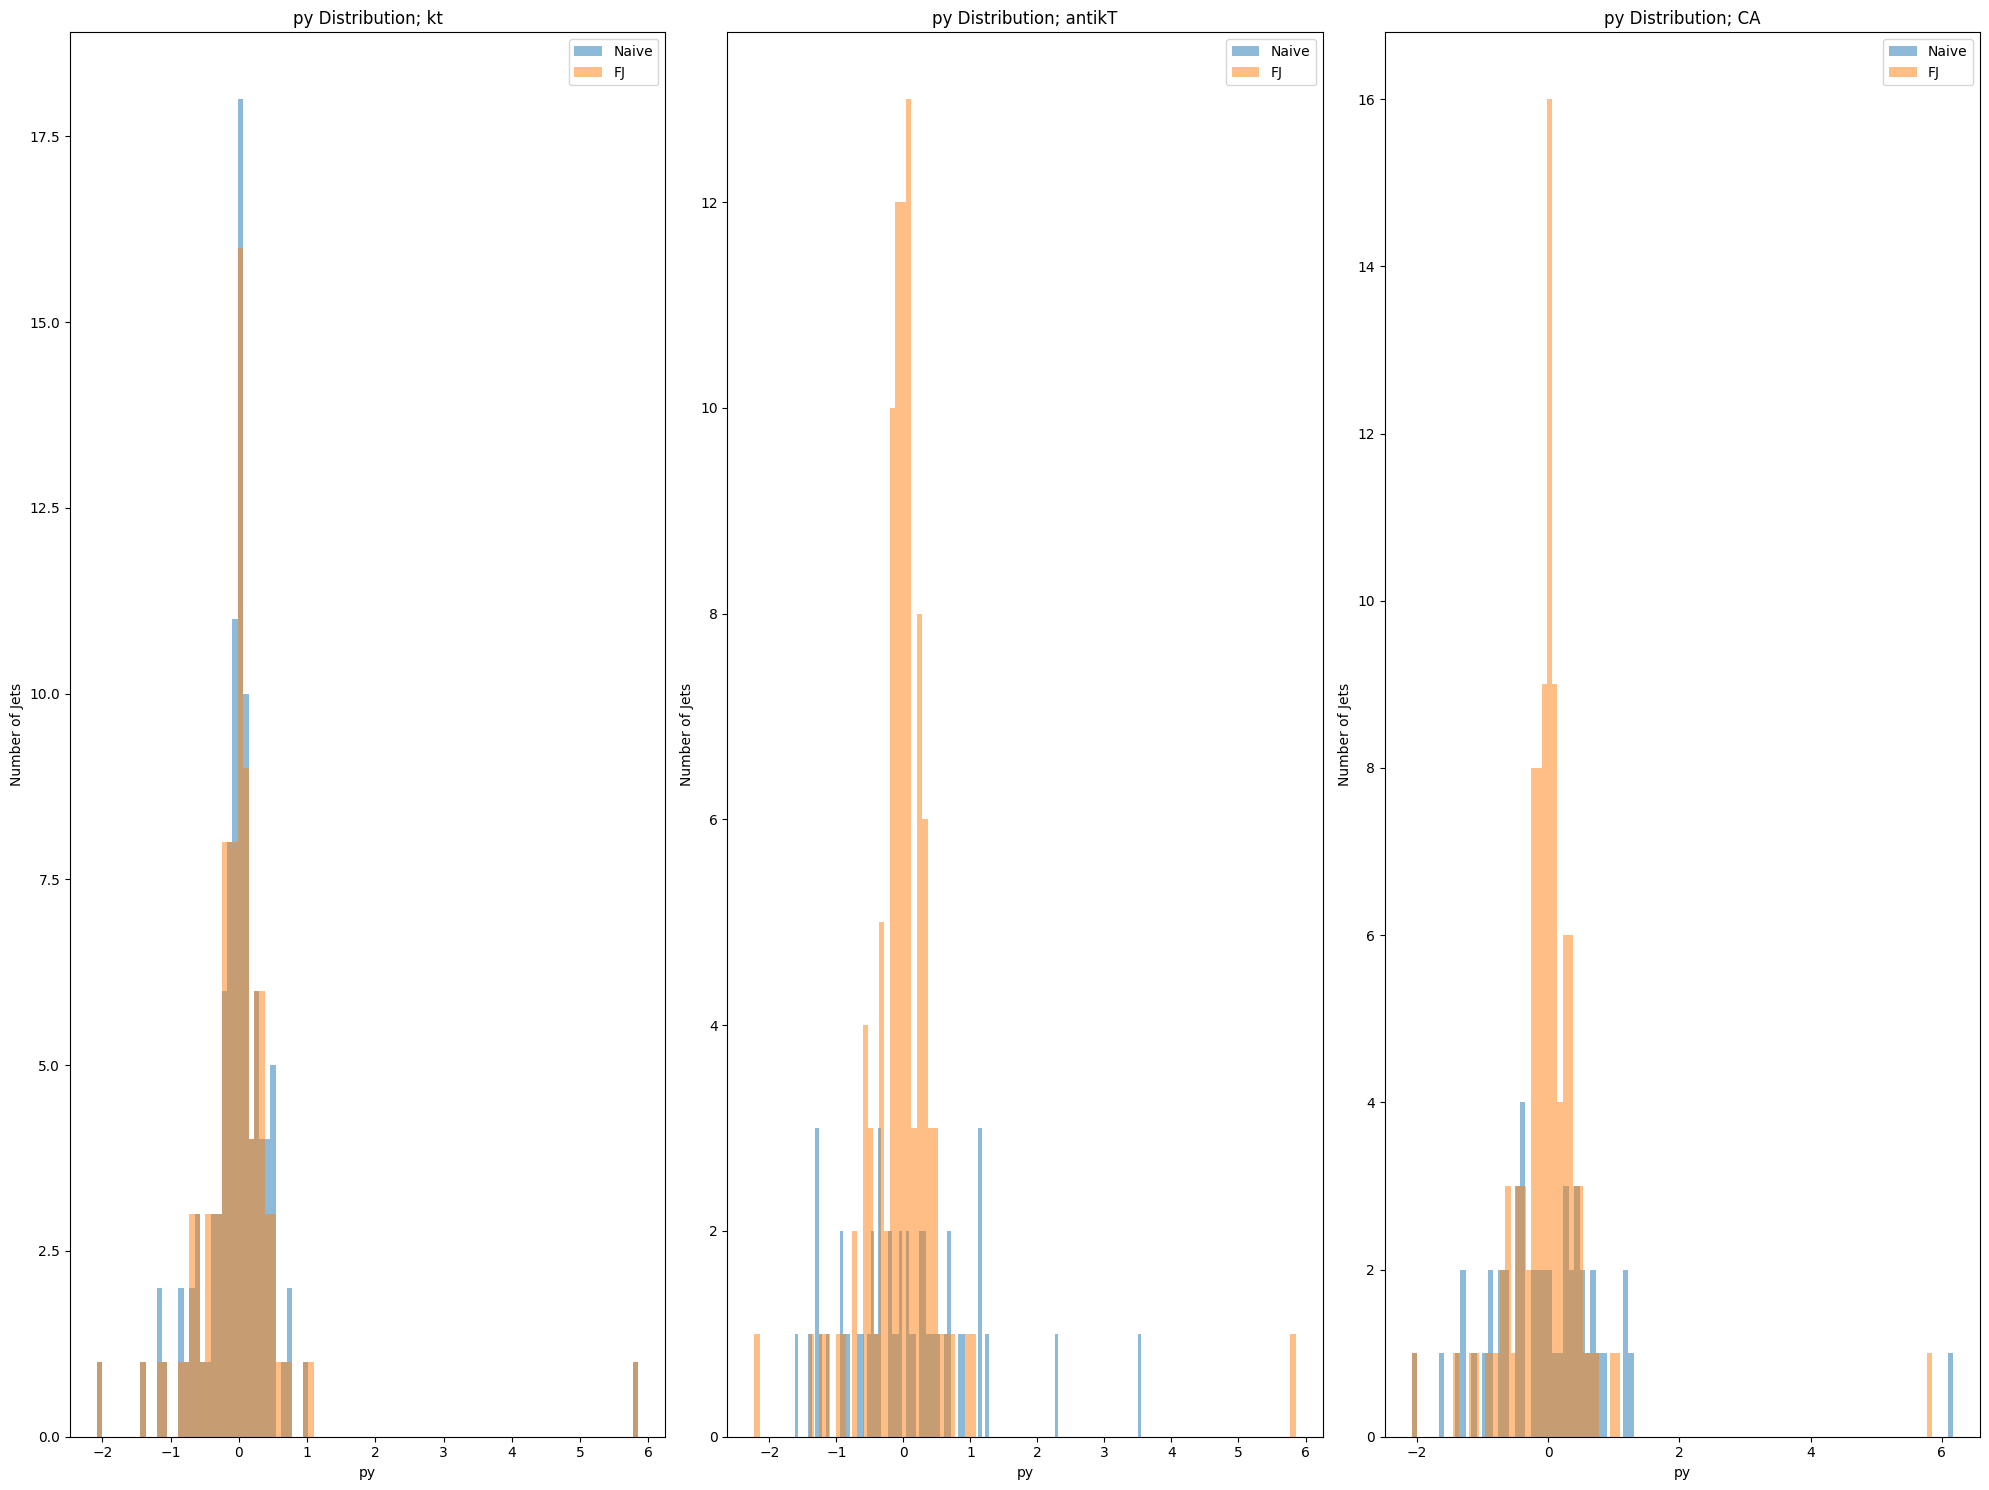

In [60]:
figpy, axespy = plt.subplots(1, 3, figsize=(20, 15))

axespy[0].hist(naive_kt_py, bins=100, alpha=0.5, label='Naive')
axespy[0].hist(fj_kt_py, bins=100, alpha=0.5, label='FJ')
axespy[0].set_xlabel('py')
axespy[0].set_ylabel('Number of Jets')
axespy[0].set_title('py Distribution; kt')
axespy[0].legend()

axespy[1].hist(naive_antikt_py, bins=100, alpha=0.5, label='Naive')
axespy[1].hist(fj_antikt_py, bins=100, alpha=0.5, label='FJ')
axespy[1].set_xlabel('py')
axespy[1].set_ylabel('Number of Jets')
axespy[1].set_title('py Distribution; antikT')
axespy[1].legend()

axespy[2].hist(naive_ca_py, bins=100, alpha=0.5, label='Naive')
axespy[2].hist(fj_ca_py, bins=100, alpha=0.5, label='FJ')
axespy[2].set_xlabel('py')
axespy[2].set_ylabel('Number of Jets')
axespy[2].set_title('py Distribution; CA')
axespy[2].legend()

plt.tight_layout()
plt.show()

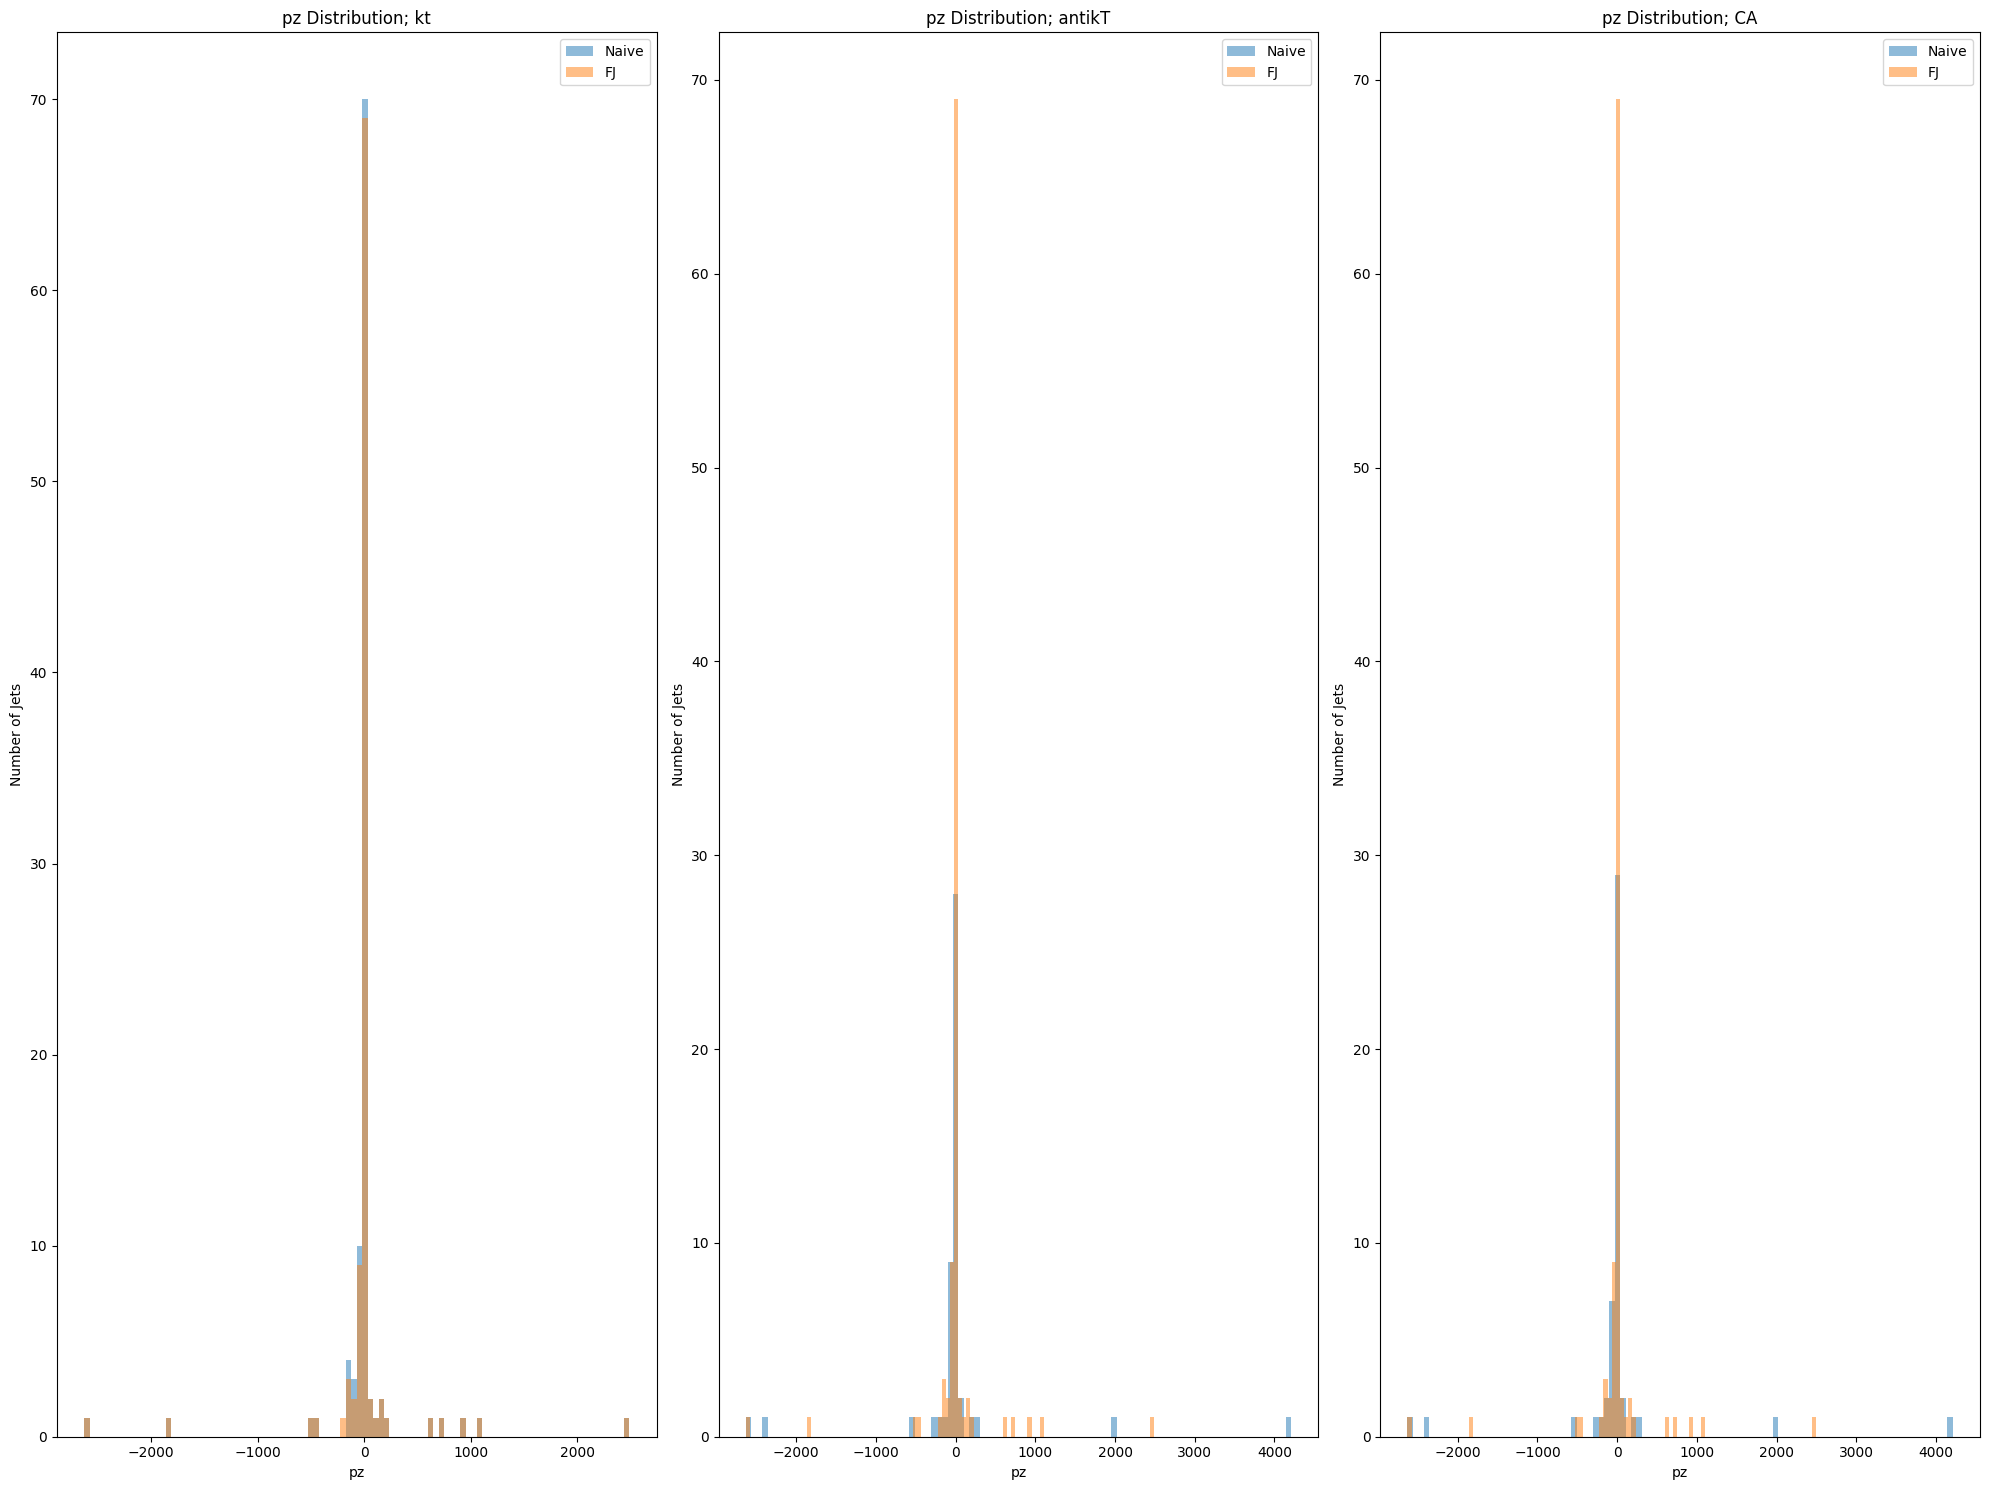

In [61]:
figpz, axespz = plt.subplots(1, 3, figsize=(20, 15))

axespz[0].hist(naive_kt_pz, bins=100, alpha=0.5, label='Naive')
axespz[0].hist(fj_kt_pz, bins=100, alpha=0.5, label='FJ')
axespz[0].set_xlabel('pz')
axespz[0].set_ylabel('Number of Jets')
axespz[0].set_title('pz Distribution; kt')
axespz[0].legend()

axespz[1].hist(naive_antikt_pz, bins=100, alpha=0.5, label='Naive')
axespz[1].hist(fj_antikt_pz, bins=100, alpha=0.5, label='FJ')
axespz[1].set_xlabel('pz')
axespz[1].set_ylabel('Number of Jets')
axespz[1].set_title('pz Distribution; antikT')
axespz[1].legend()

axespz[2].hist(naive_ca_pz, bins=100, alpha=0.5, label='Naive')
axespz[2].hist(fj_ca_pz, bins=100, alpha=0.5, label='FJ')
axespz[2].set_xlabel('pz')
axespz[2].set_ylabel('Number of Jets')
axespz[2].set_title('pz Distribution; CA')
axespz[2].legend()

plt.tight_layout()
plt.show()
#



In [63]:
naive_kt_pt = tree_naive_kT["pT"].array()
naive_antikt_pt = tree_naive_antikt["pT"].array()
naive_ca_pt = tree_naive_ca["pT"].array()

fj_kt_pt = tree_fj_kT["pT"].array()
fj_antikt_pt = tree_fj_antikt["pT"].array()
fj_ca_pt = tree_fj_ca["pT"].array()

naive_kt_phi = tree_naive_kT["phi"].array()
naive_antikt_phi = tree_naive_antikt["phi"].array()
naive_ca_phi = tree_naive_ca["phi"].array()

fj_kt_phi = tree_fj_kT["phi"].array()
fj_antikt_phi = tree_fj_antikt["phi"].array()
fj_ca_phi = tree_fj_ca["phi"].array()

naive_kt_eta = tree_naive_kT["eta"].array()
naive_antikt_eta = tree_naive_antikt["eta"].array()
naive_ca_eta = tree_naive_ca["eta"].array()

fj_kt_eta = tree_fj_kT["eta"].array()
fj_antikt_eta = tree_fj_antikt["eta"].array()
fj_ca_eta = tree_fj_ca["eta"].array()

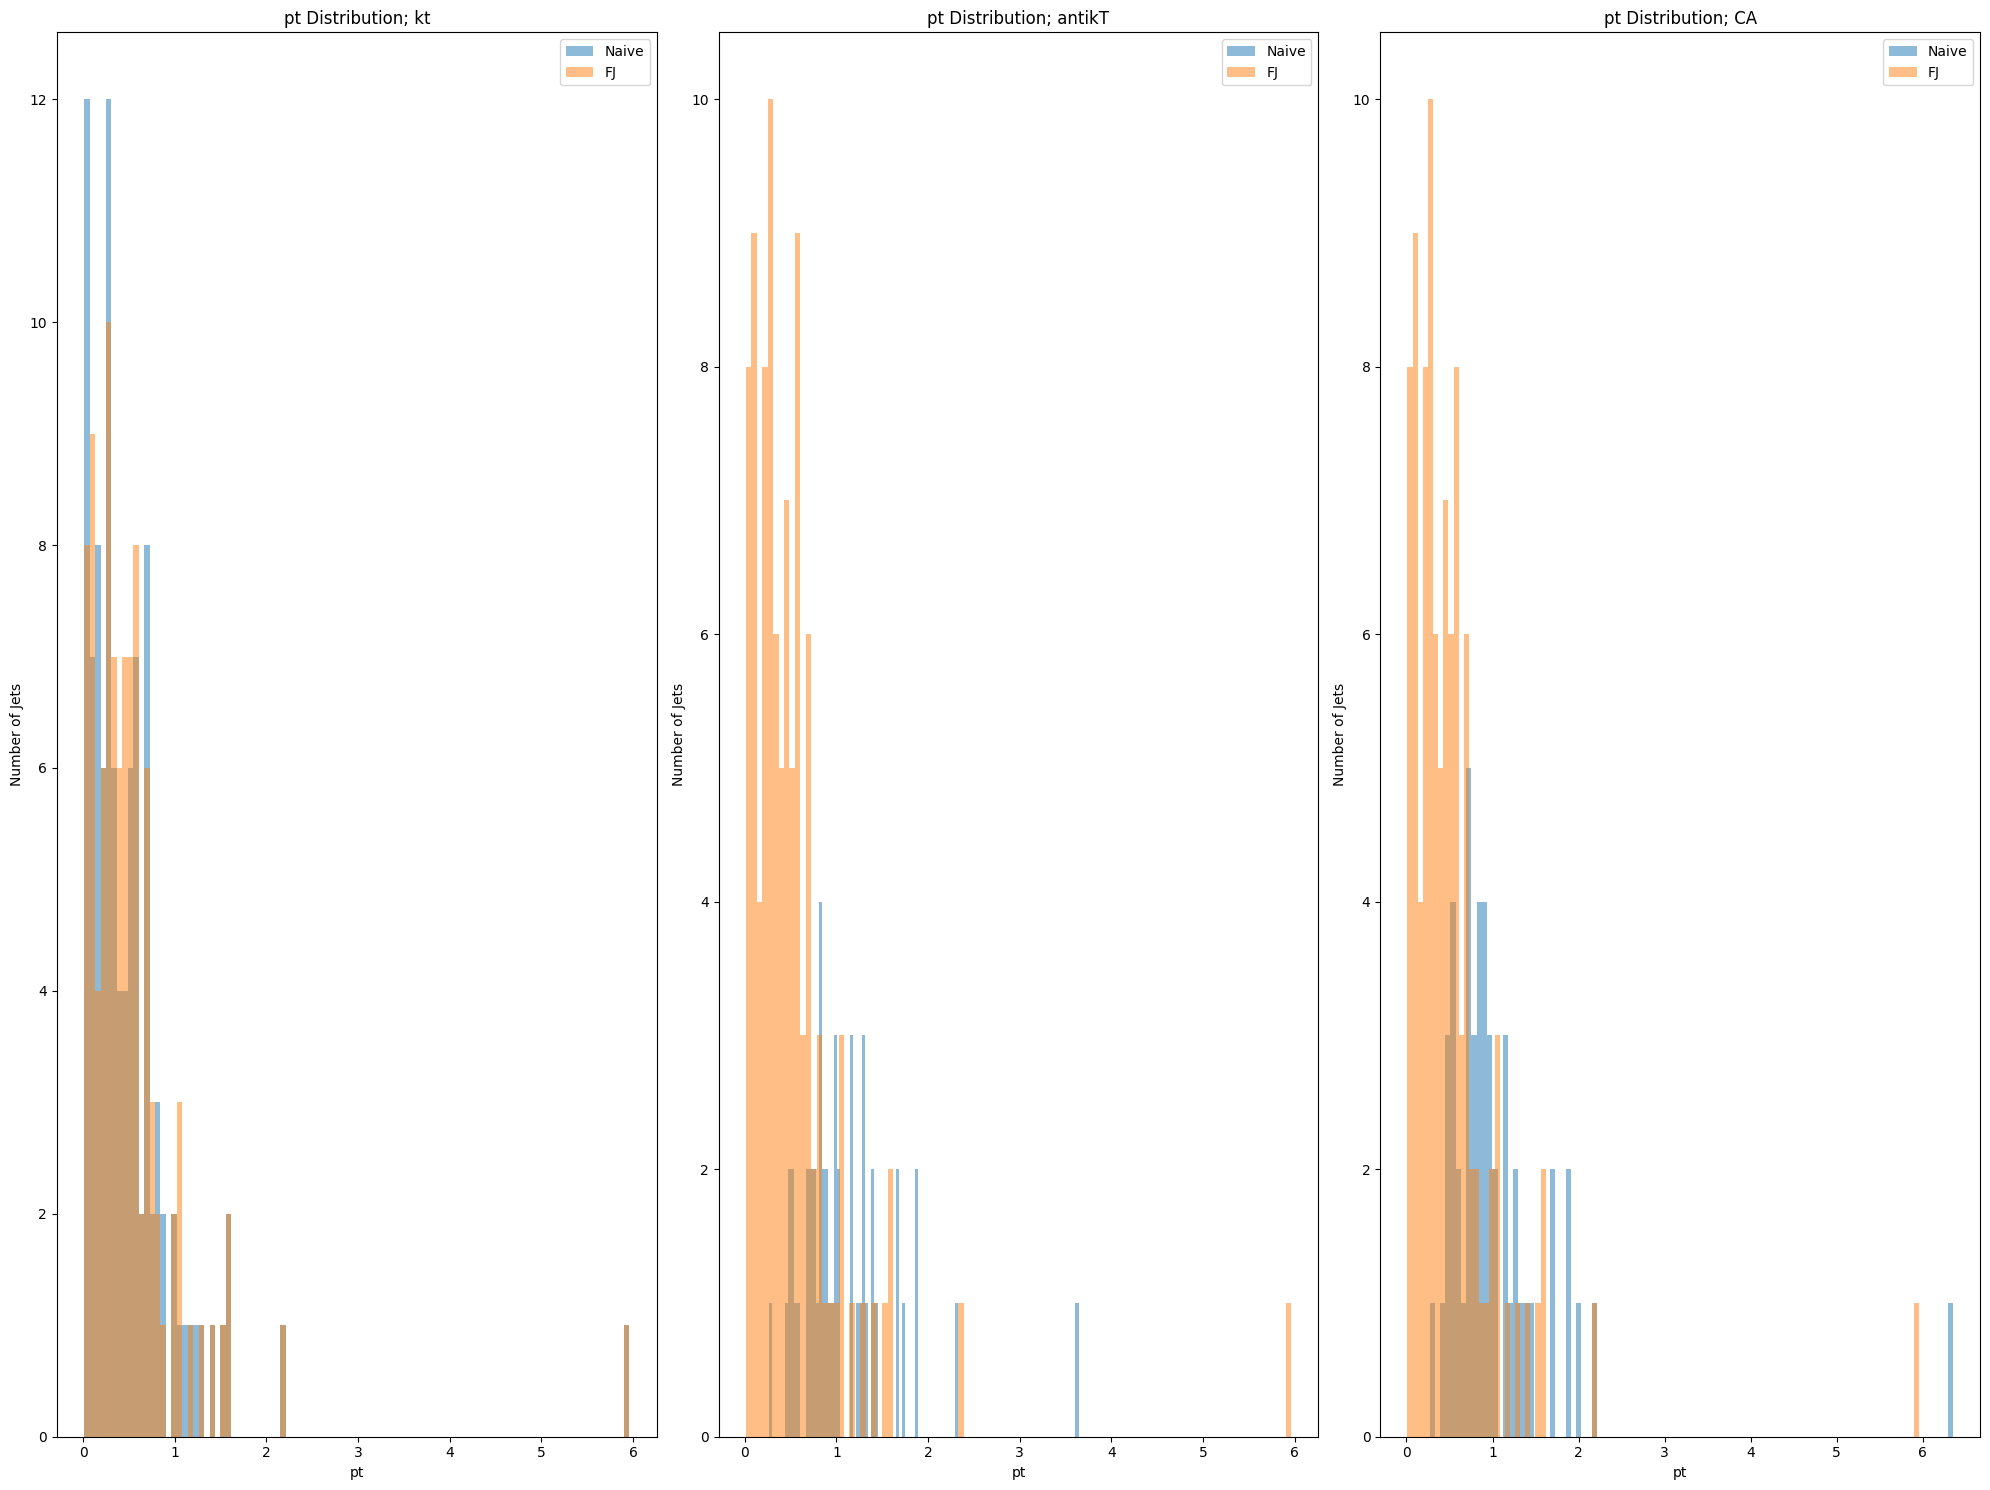

In [65]:
#Now in collider coordinates:

figpt, axespt = plt.subplots(1, 3, figsize=(20, 15))

axespt[0].hist(naive_kt_pt, bins=100, alpha=0.5, label='Naive')
axespt[0].hist(fj_kt_pt, bins=100, alpha=0.5, label='FJ')
axespt[0].set_xlabel('pt')
axespt[0].set_ylabel('Number of Jets')
axespt[0].set_title('pt Distribution; kt')
axespt[0].legend()

axespt[1].hist(naive_antikt_pt, bins=100, alpha=0.5, label='Naive')
axespt[1].hist(fj_antikt_pt, bins=100, alpha=0.5, label='FJ')
axespt[1].set_xlabel('pt')
axespt[1].set_ylabel('Number of Jets')
axespt[1].set_title('pt Distribution; antikT')
axespt[1].legend()

axespt[2].hist(naive_ca_pt, bins=100, alpha=0.5, label='Naive')
axespt[2].hist(fj_ca_pt, bins=100, alpha=0.5, label='FJ')
axespt[2].set_xlabel('pt')
axespt[2].set_ylabel('Number of Jets')
axespt[2].set_title('pt Distribution; CA')
axespt[2].legend()

plt.tight_layout()
plt.show()
#



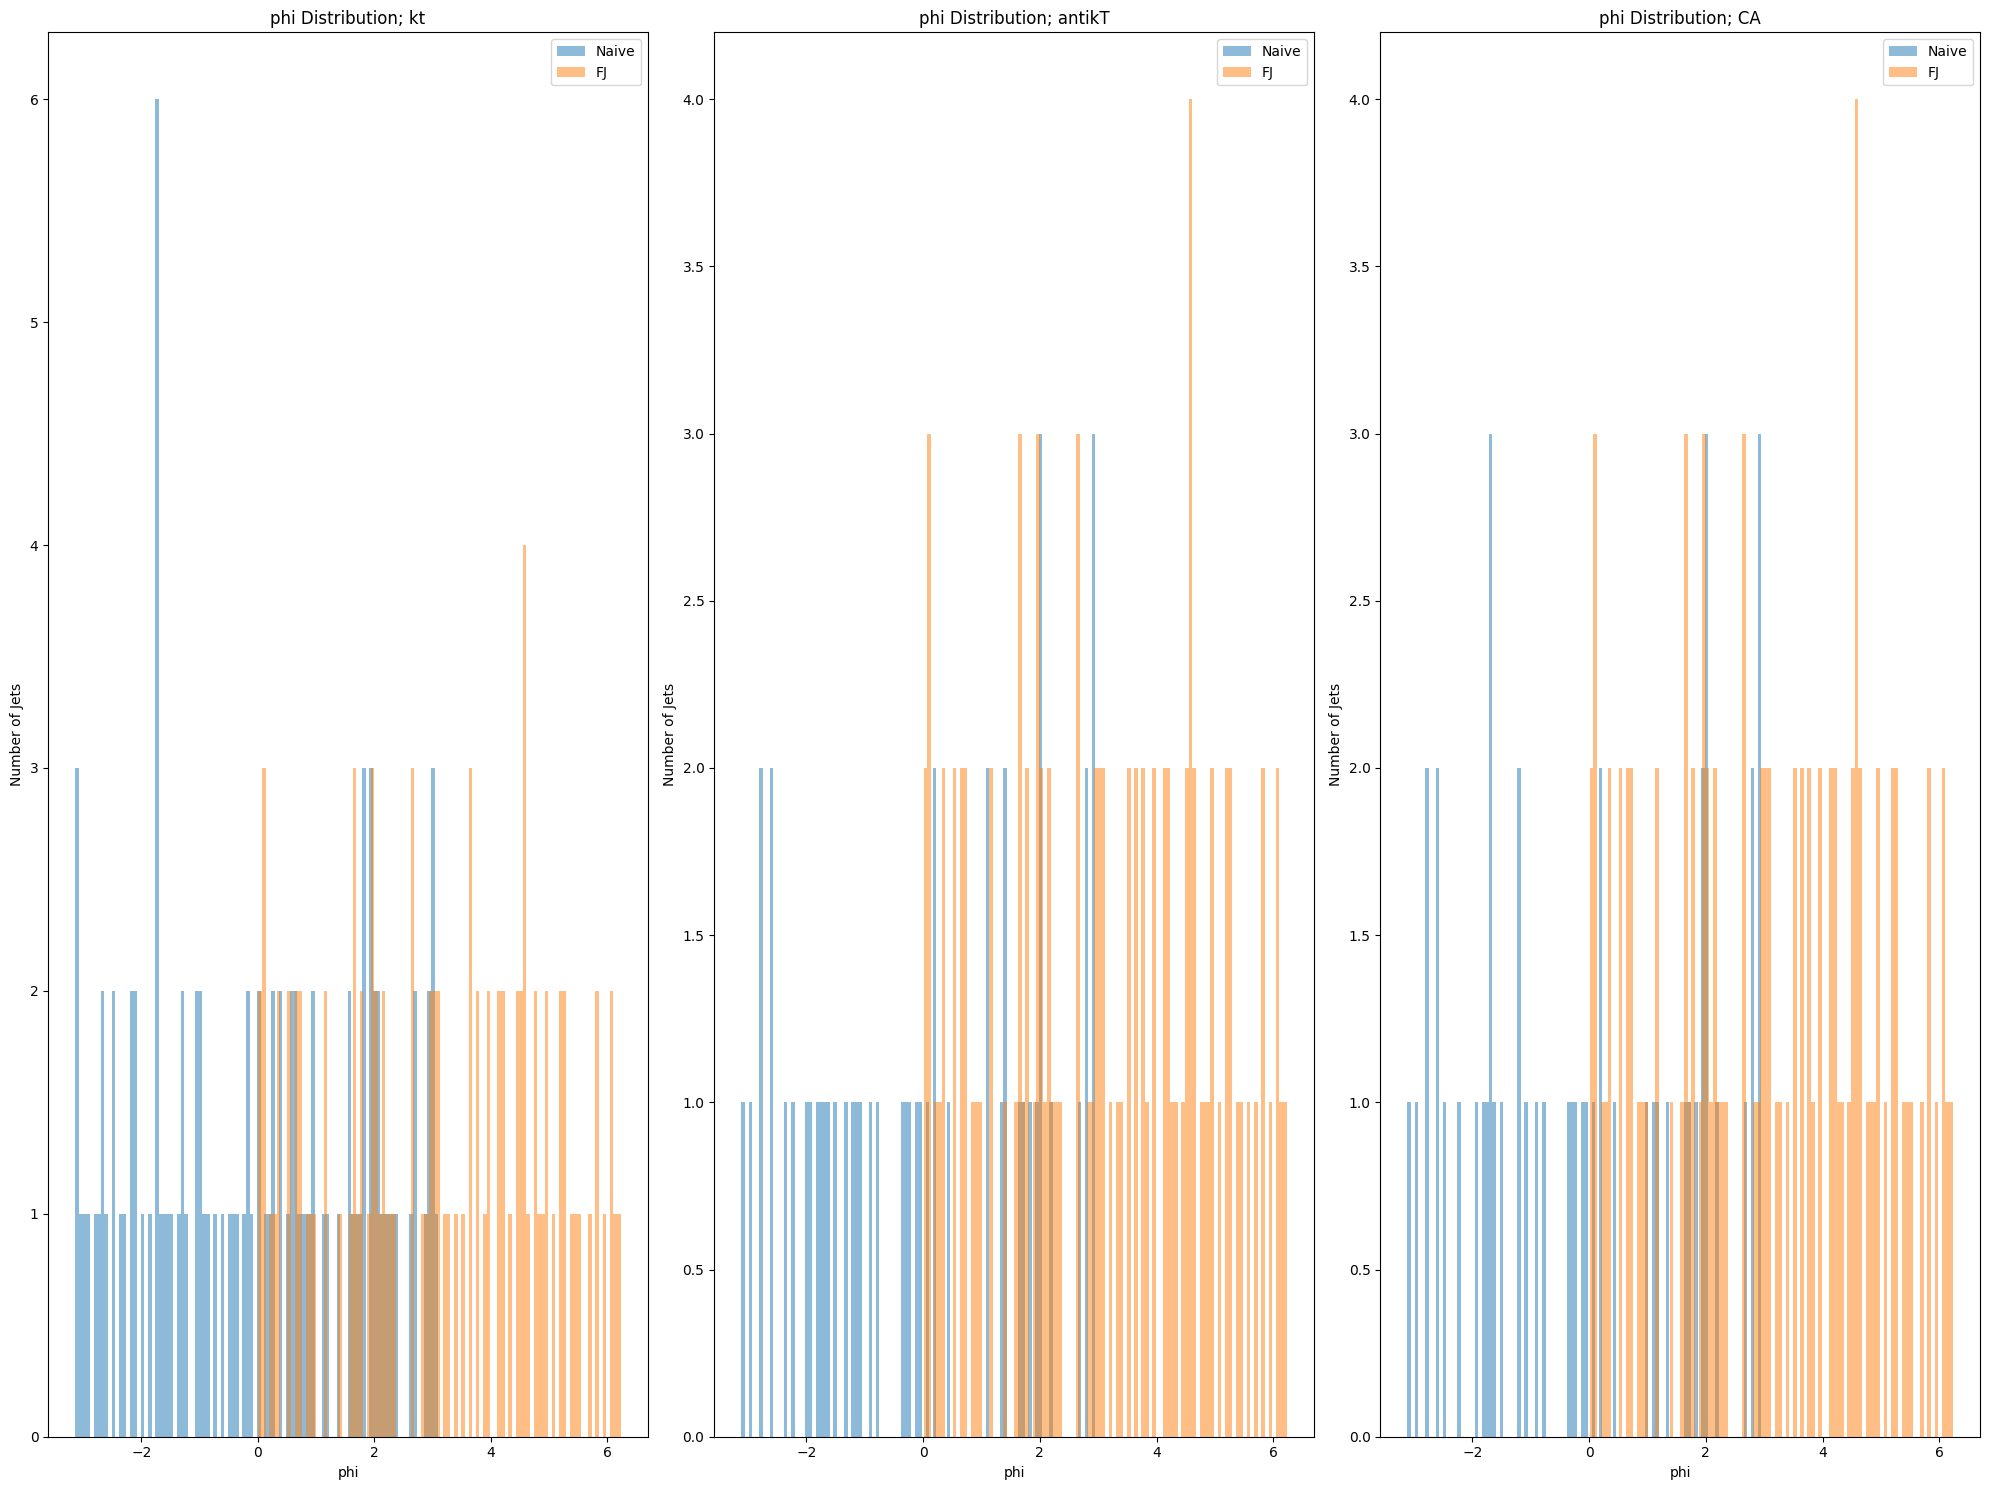

In [66]:
figphi, axesphi = plt.subplots(1, 3, figsize=(20, 15))

axesphi[0].hist(naive_kt_phi, bins=100, alpha=0.5, label='Naive')
axesphi[0].hist(fj_kt_phi, bins=100, alpha=0.5, label='FJ')
axesphi[0].set_xlabel('phi')
axesphi[0].set_ylabel('Number of Jets')
axesphi[0].set_title('phi Distribution; kt')
axesphi[0].legend()

axesphi[1].hist(naive_antikt_phi, bins=100, alpha=0.5, label='Naive')
axesphi[1].hist(fj_antikt_phi, bins=100, alpha=0.5, label='FJ')
axesphi[1].set_xlabel('phi')
axesphi[1].set_ylabel('Number of Jets')
axesphi[1].set_title('phi Distribution; antikT')
axesphi[1].legend()

axesphi[2].hist(naive_ca_phi, bins=100, alpha=0.5, label='Naive')
axesphi[2].hist(fj_ca_phi, bins=100, alpha=0.5, label='FJ')
axesphi[2].set_xlabel('phi')
axesphi[2].set_ylabel('Number of Jets')
axesphi[2].set_title('phi Distribution; CA')
axesphi[2].legend()

plt.tight_layout()
plt.show()


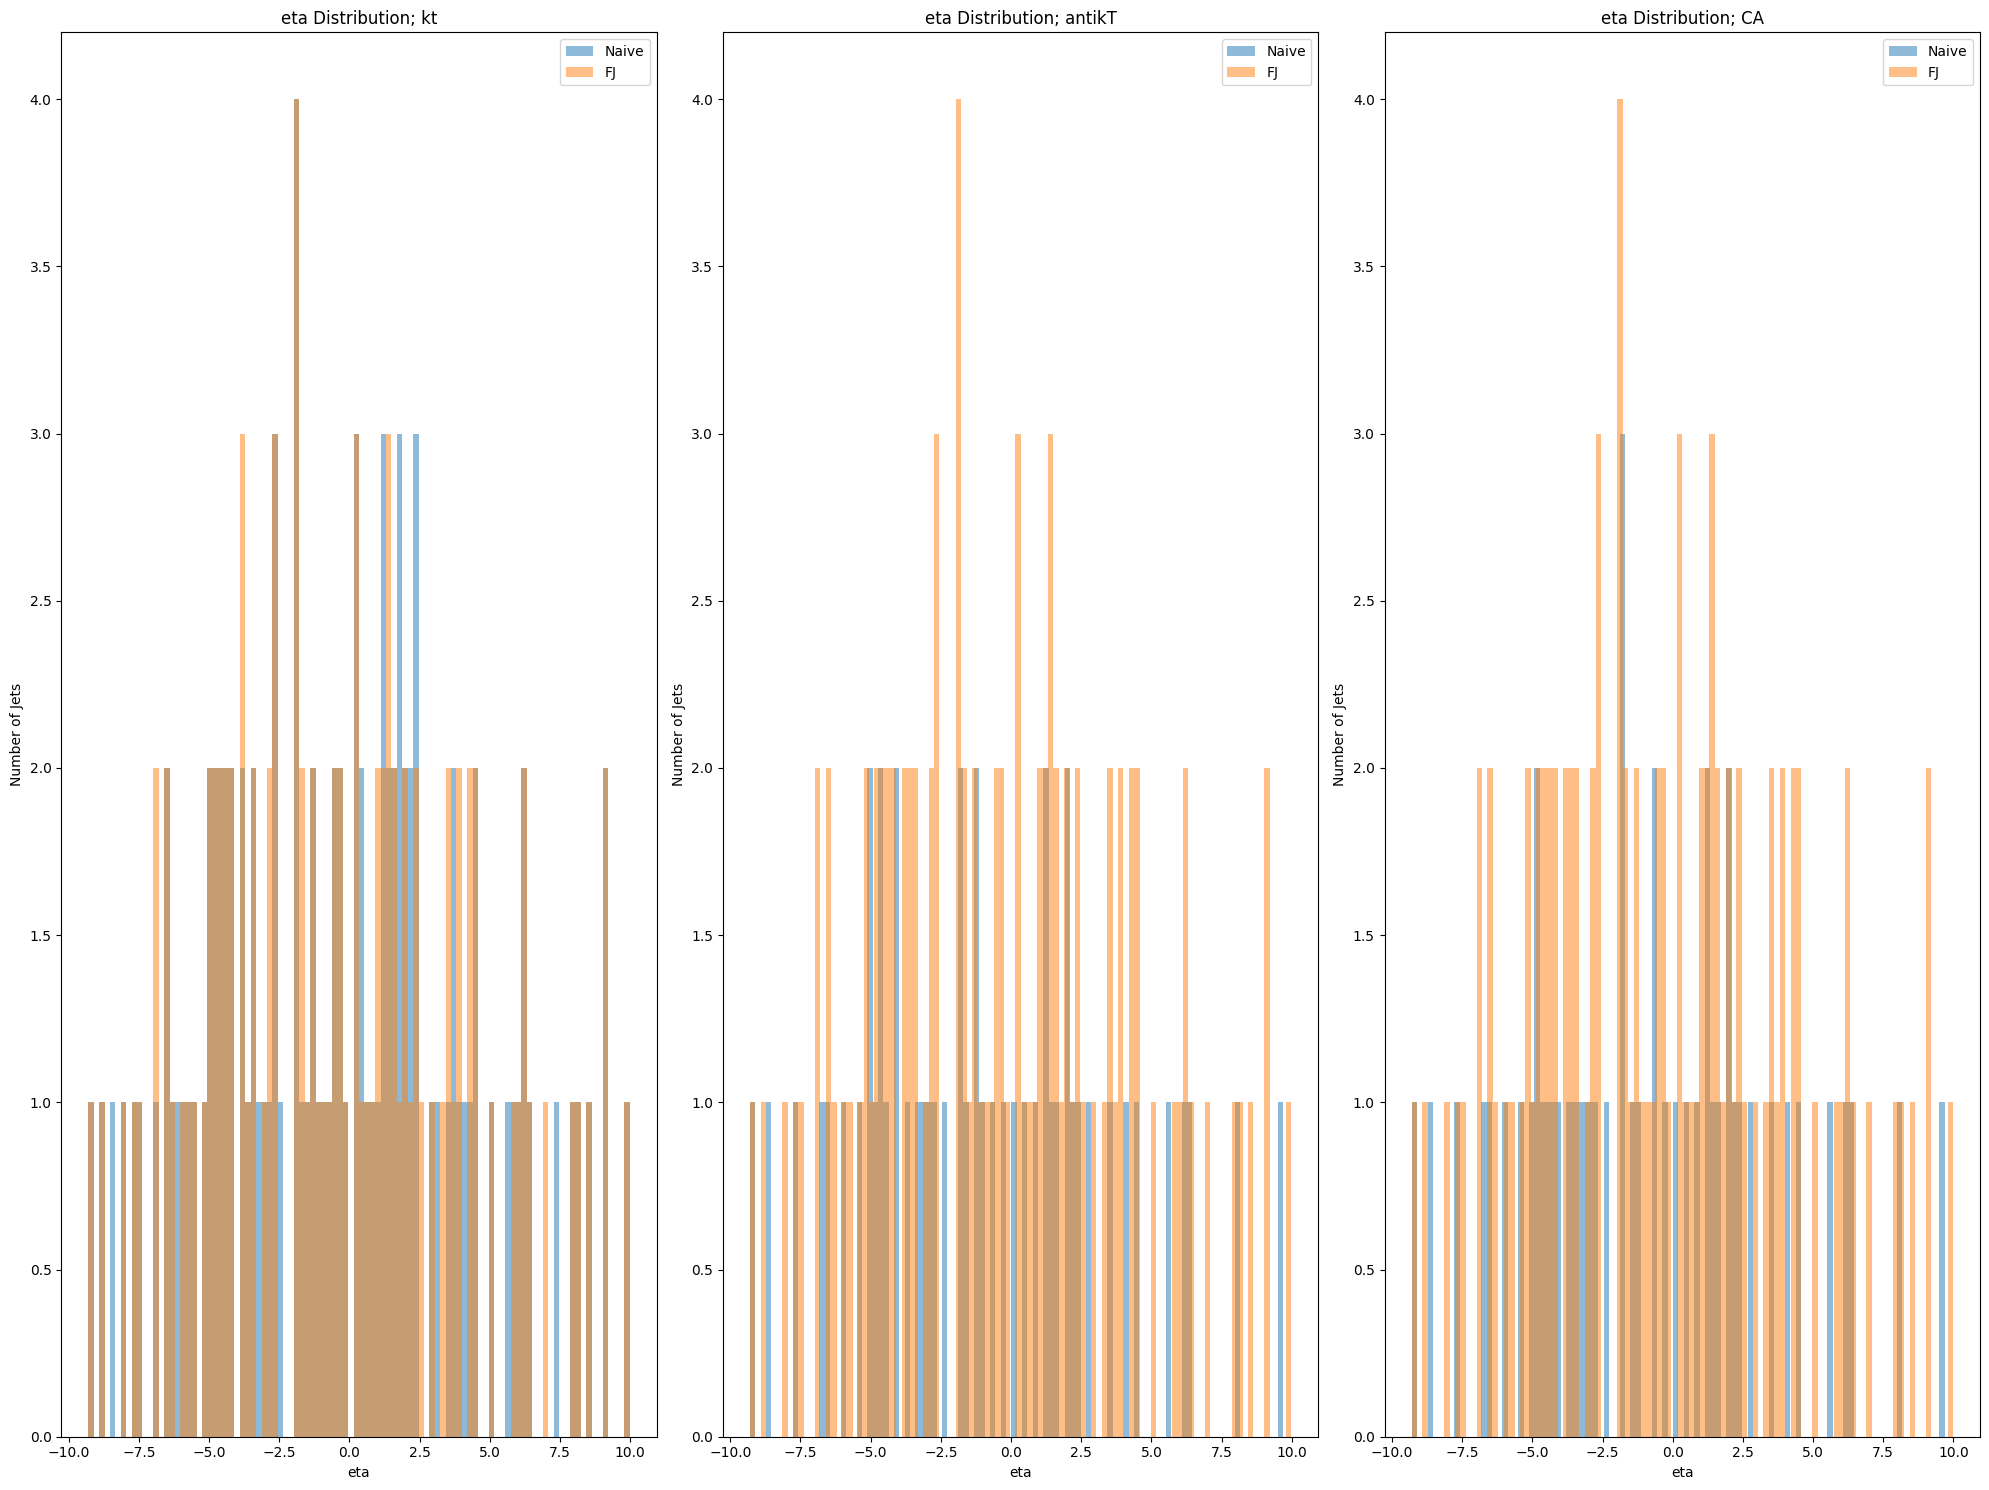

In [67]:
fig_eta, axes_eta = plt.subplots(1, 3, figsize=(20,15))

axes_eta[0].hist(naive_kt_eta, bins=100, alpha=0.5, label='Naive')
axes_eta[0].hist(fj_kt_eta, bins=100, alpha=0.5, label='FJ')
axes_eta[0].set_xlabel('eta')
axes_eta[0].set_ylabel('Number of Jets')
axes_eta[0].set_title('eta Distribution; kt')
axes_eta[0].legend()

axes_eta[1].hist(naive_antikt_eta, bins=100, alpha=0.5, label='Naive')
axes_eta[1].hist(fj_antikt_eta, bins=100, alpha=0.5, label='FJ')
axes_eta[1].set_xlabel('eta')
axes_eta[1].set_ylabel('Number of Jets')
axes_eta[1].set_title('eta Distribution; antikT')
axes_eta[1].legend()

axes_eta[2].hist(naive_ca_eta, bins=100, alpha=0.5, label='Naive')
axes_eta[2].hist(fj_ca_eta, bins=100, alpha=0.5, label='FJ')
axes_eta[2].set_xlabel('eta')
axes_eta[2].set_ylabel('Number of Jets')
axes_eta[2].set_title('eta Distribution; CA')
axes_eta[2].legend()

plt.tight_layout()
plt.show()
